![alt text](kayfaio_logo2-1.jpg)
# **Kayfa Academy Internship**
# Task 1: HR Attrition Dataset Analysis

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Data loading

In [3]:
train_df = pd.read_csv("dataset/train.csv")
train_df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [4]:
test_df = pd.read_csv("dataset/test.csv")
test_df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,52685,36,Male,13,Healthcare,8029,Excellent,High,Average,1,...,1,Mid,Large,22,No,No,No,Poor,Medium,Stayed
1,30585,35,Male,7,Education,4563,Good,High,Average,1,...,4,Entry,Medium,27,No,No,No,Good,High,Left
2,54656,50,Male,7,Education,5583,Fair,High,Average,3,...,2,Senior,Medium,76,No,No,Yes,Good,Low,Stayed
3,33442,58,Male,44,Media,5525,Fair,Very High,High,0,...,4,Entry,Medium,96,No,No,No,Poor,Low,Left
4,15667,39,Male,24,Education,4604,Good,High,Average,0,...,6,Mid,Large,45,Yes,No,No,Good,High,Stayed


In [5]:
df = pd.concat([train_df, test_df], ignore_index=True)
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [6]:
print("Train Length:", len(train_df), '\nTest Length:', len(test_df), '\n\nTotal Length:',len(df))

Train Length: 59598 
Test Length: 14900 

Total Length: 74498


In [7]:
del train_df, test_df

In [7]:
df.columns

Index(['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role',
       'Monthly Income', 'Work-Life Balance', 'Job Satisfaction',
       'Performance Rating', 'Number of Promotions', 'Overtime',
       'Distance from Home', 'Education Level', 'Marital Status',
       'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure',
       'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities',
       'Company Reputation', 'Employee Recognition', 'Attrition'],
      dtype='str')

#### Change column names into snake case

In [8]:
df.columns = df.columns.str.lower().str.replace(' ','_')
print("New column names:",df.columns, sep='\n\n')

New column names:

Index(['employee_id', 'age', 'gender', 'years_at_company', 'job_role',
       'monthly_income', 'work-life_balance', 'job_satisfaction',
       'performance_rating', 'number_of_promotions', 'overtime',
       'distance_from_home', 'education_level', 'marital_status',
       'number_of_dependents', 'job_level', 'company_size', 'company_tenure',
       'remote_work', 'leadership_opportunities', 'innovation_opportunities',
       'company_reputation', 'employee_recognition', 'attrition'],
      dtype='str')


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74498 entries, 0 to 74497
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   employee_id               74498 non-null  int64
 1   age                       74498 non-null  int64
 2   gender                    74498 non-null  str  
 3   years_at_company          74498 non-null  int64
 4   job_role                  74498 non-null  str  
 5   monthly_income            74498 non-null  int64
 6   work-life_balance         74498 non-null  str  
 7   job_satisfaction          74498 non-null  str  
 8   performance_rating        74498 non-null  str  
 9   number_of_promotions      74498 non-null  int64
 10  overtime                  74498 non-null  str  
 11  distance_from_home        74498 non-null  int64
 12  education_level           74498 non-null  str  
 13  marital_status            74498 non-null  str  
 14  number_of_dependents      74498 non-null  int64
 

In [10]:
df.describe()

,employee_id,age,years_at_company,monthly_income,number_of_promotions,distance_from_home,number_of_dependents,company_tenure
count,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000
mean,37249.500000,38.529746,15.721603,7299.379514,0.832935,49.991584,1.650326,55.727456
std,21505.864514,12.083456,11.223744,2152.508566,0.995289,28.513611,1.553633,25.399349
min,1.000000,18.000000,1.000000,1226.000000,0.000000,1.000000,0.000000,2.000000
25%,18625.250000,28.000000,7.000000,5652.000000,0.000000,25.000000,0.000000,36.000000
50%,37249.500000,39.000000,13.000000,7348.000000,1.000000,50.000000,1.000000,56.000000
75%,55873.750000,49.000000,23.000000,8876.000000,2.000000,75.000000,3.000000,76.000000
max,74498.000000,59.000000,51.000000,16149.000000,4.000000,99.000000,6.000000,128.000000


In [11]:
df.isnull().sum()

employee_id                 0
age                         0
gender                      0
years_at_company            0
job_role                    0
monthly_income              0
work-life_balance           0
job_satisfaction            0
performance_rating          0
number_of_promotions        0
overtime                    0
distance_from_home          0
education_level             0
marital_status              0
number_of_dependents        0
job_level                   0
company_size                0
company_tenure              0
remote_work                 0
leadership_opportunities    0
innovation_opportunities    0
company_reputation          0
employee_recognition        0
attrition                   0
dtype: int64

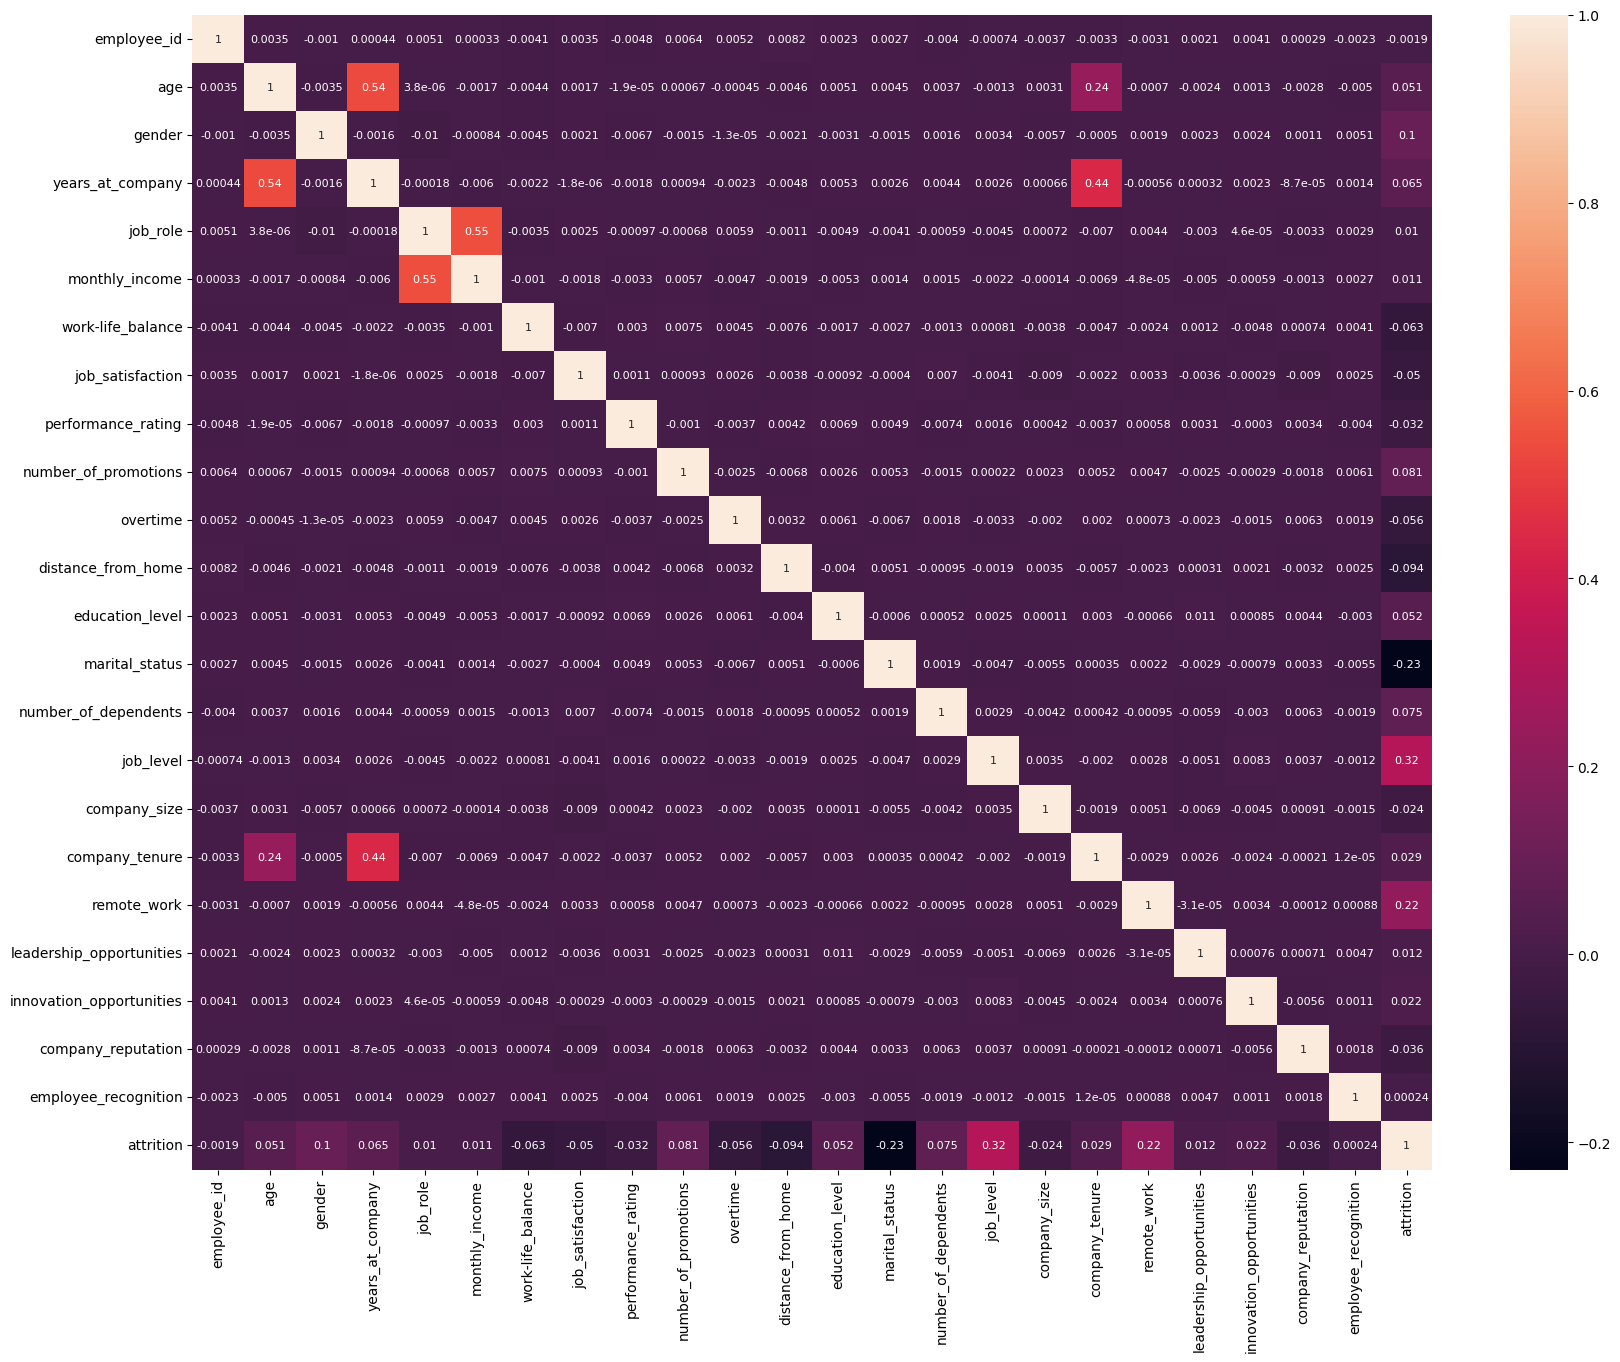

In [12]:
df2 = df.copy()
for c in df2.columns:
    if df2[c].dtype.type == str:
        df2[c] = df2[c].astype('category').cat.codes

plt.figure(figsize=(20,15))
sns.heatmap(df2.corr(), annot=True, annot_kws={'size': 8})
plt.show()
del df2

In [13]:
df.head(2)

,employee_id,age,gender,years_at_company,job_role,monthly_income,work-life_balance,job_satisfaction,performance_rating,number_of_promotions,...,number_of_dependents,job_level,company_size,company_tenure,remote_work,leadership_opportunities,innovation_opportunities,company_reputation,employee_recognition,attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed


In [ ]:
df.to_csv('data.csv', index=False)

## Data Analysis

In [15]:
df['age'].mean()

np.float64(38.52974576498698)

In [16]:
df.groupby('attrition')['monthly_income'].mean()

attrition
Left      7275.183913
Stayed    7321.251278
Name: monthly_income, dtype: float64

#### Check the outliers

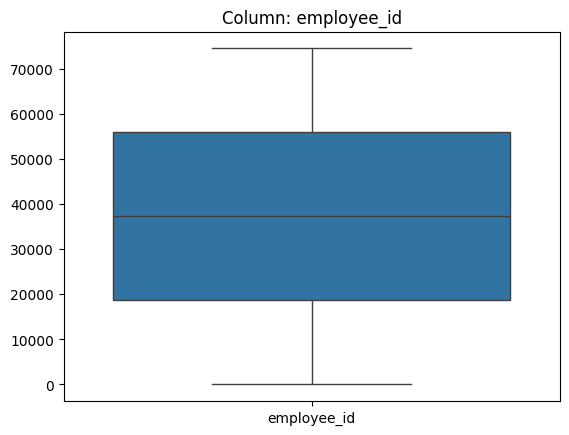

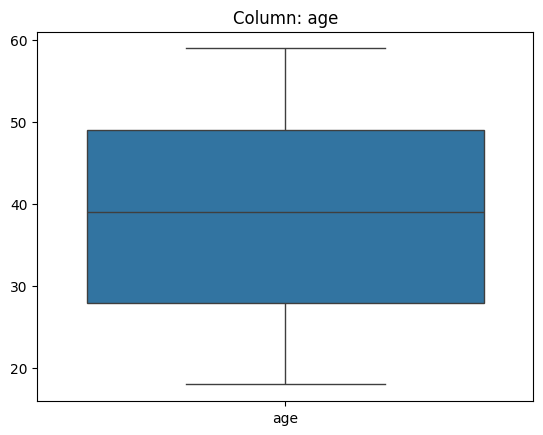

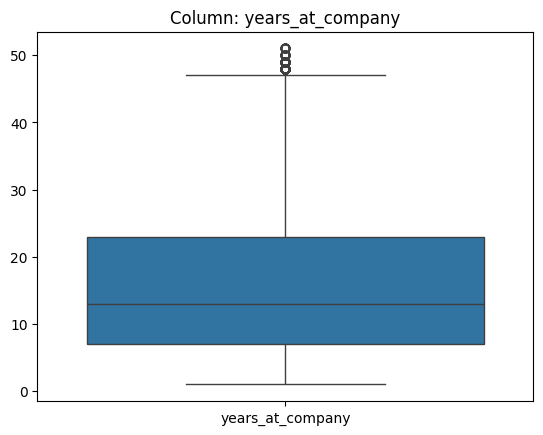

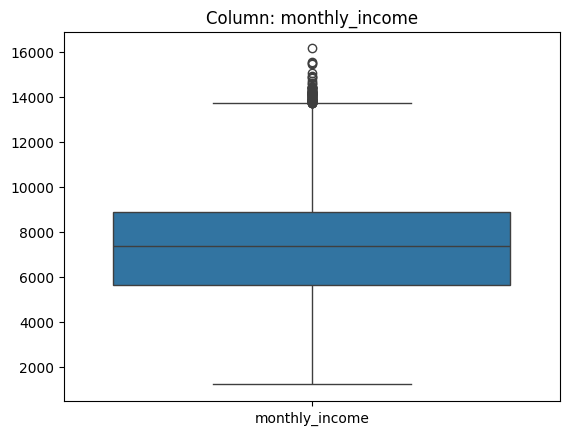

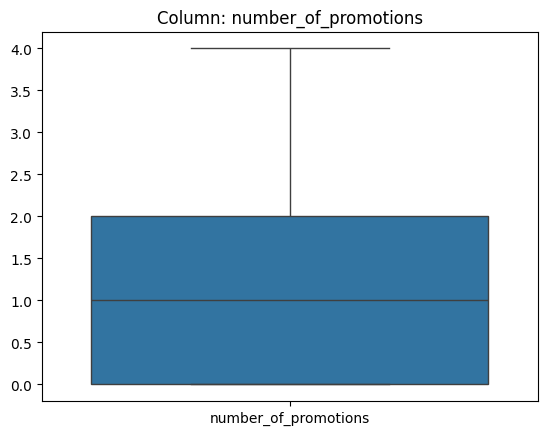

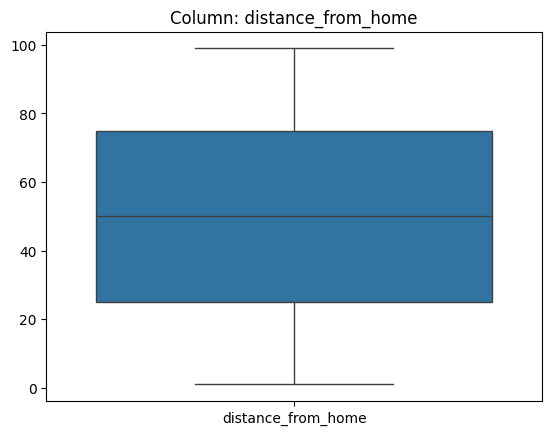

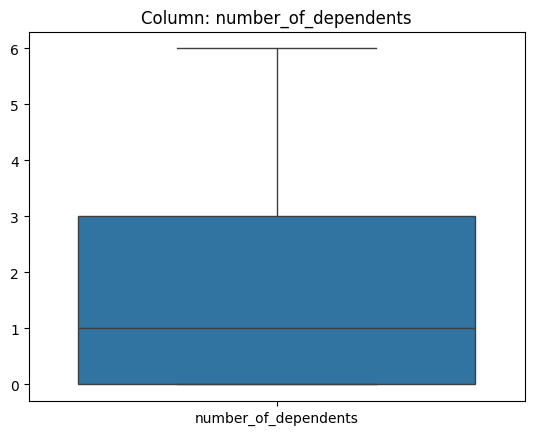

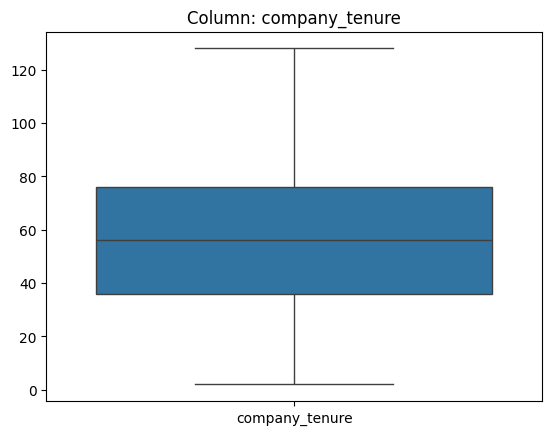

In [17]:
for c in df.columns:
    if df[c].dtype != 'str':
        sns.boxplot([df[c]], )
        plt.title(f"Column: {c}")
        plt.show()

In [18]:
q1 = df['monthly_income'].quantile(0.25)
q3 = df['monthly_income'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1-1.5*iqr
upper_bound = q3+1.5*iqr

In [19]:
print("Lower bound:",lower_bound, '\nUpper bound:',upper_bound)

Lower bound: 816.0 
Upper bound: 13712.0


In [20]:
df2 = df[df['monthly_income'] <= upper_bound]

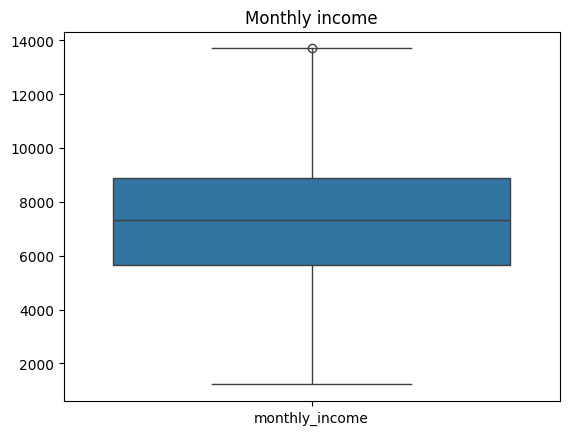

In [21]:
sns.boxplot([df2['monthly_income']])
plt.title("Monthly income")
plt.show()

---

#### what is the average monthly salaries ratio for attrition and non attrition employees?

In [22]:
df2.groupby('attrition')['monthly_income'].mean()

attrition
Left      7268.651612
Stayed    7315.637457
Name: monthly_income, dtype: float64

#### what is the number of dependents ratio for attrition and non attrition

In [23]:
df.groupby('attrition')['number_of_dependents'].mean()

attrition
Left      1.528414
Stayed    1.760530
Name: number_of_dependents, dtype: float64

#### what is the employee recognition chance ratio for attrition only employees

In [24]:
df[df['attrition']=='Left'].groupby('employee_recognition')['attrition'].count().sort_values(ascending=False)

employee_recognition
Low          14163
Medium       10784
High          8734
Very High     1689
Name: attrition, dtype: int64

Text(0, 0.5, 'Number of attrition employees')

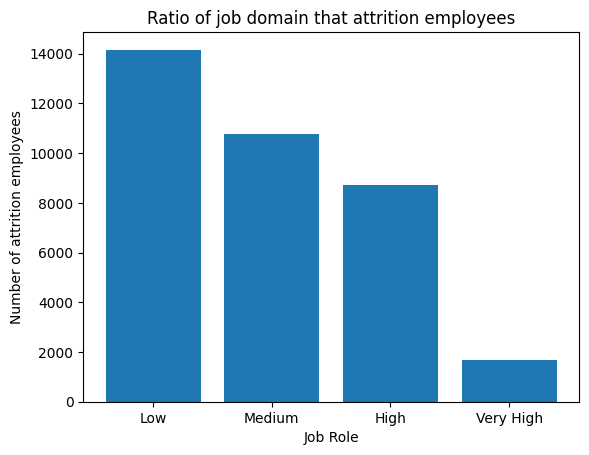

In [ ]:
plt.Figure()
plt.bar(df[df['attrition']=='Left'].groupby('employee_recognition')['attrition'].count().sort_values(ascending=False).index, 
        df[df['attrition']=='Left'].groupby('employee_recognition')['attrition'].count().sort_values(ascending=False).values)
plt.title("Ratio of employee recognition for attrition employees")
plt.xlabel("Job Role")
plt.ylabel("Number of attrition employees")

---

#### what is the job domain ratio for attrition only employees

In [26]:
df[df['attrition']=='Left'].groupby('job_role')['attrition'].count()

job_role
Education     7636
Finance       4903
Healthcare    8112
Media         5620
Technology    9099
Name: attrition, dtype: int64

Text(0, 0.5, 'Number of attrition employees')

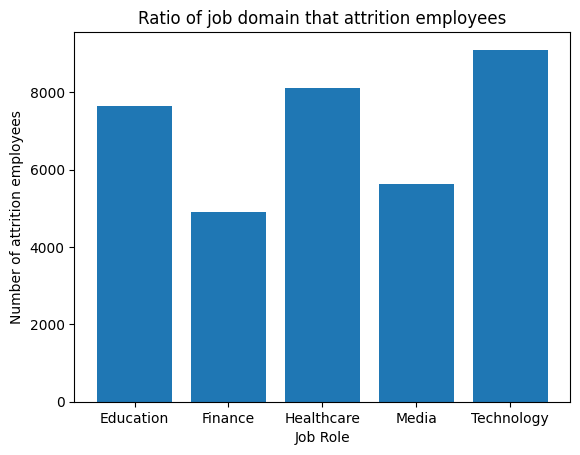

In [27]:
plt.Figure()
plt.bar(df[df['attrition']=='Left'].groupby('job_role')['attrition'].count().index, 
        df[df['attrition']=='Left'].groupby('job_role')['attrition'].count().values)
plt.title("Ratio of job domain that attrition employees")
plt.xlabel("Job Role")
plt.ylabel("Number of attrition employees")

---

#### what is the remote work ratio for attrition only employees

In [28]:
df[df['attrition']=='Left'].groupby('remote_work')['attrition'].count()

remote_work
No     31861
Yes     3509
Name: attrition, dtype: int64

Text(0, 0.5, 'Number of attrition employees')

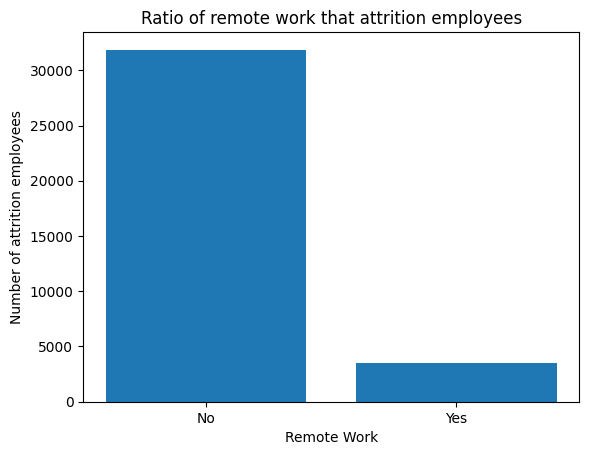

In [29]:
plt.Figure()
plt.bar(df[df['attrition']=='Left'].groupby('remote_work')['attrition'].count().index, 
        df[df['attrition']=='Left'].groupby('remote_work')['attrition'].count().values)

plt.title("Ratio of remote work that attrition employees")
plt.xlabel("Remote Work")
plt.ylabel("Number of attrition employees")

---

#### what is the destance from home ratio for attrition and non attrition only for non remote (onsite) employtees

In [30]:
df[df['attrition']=='Left'].groupby('remote_work')['distance_from_home'].count()

remote_work
No     31861
Yes     3509
Name: distance_from_home, dtype: int64

In [31]:
df.head()

,employee_id,age,gender,years_at_company,job_role,monthly_income,work-life_balance,job_satisfaction,performance_rating,number_of_promotions,...,number_of_dependents,job_level,company_size,company_tenure,remote_work,leadership_opportunities,innovation_opportunities,company_reputation,employee_recognition,attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [32]:
df['distance_from_home']

0        22
1        21
2        11
3        27
4        71
         ..
74493    40
74494    45
74495     4
74496    13
74497    64
Name: distance_from_home, Length: 74498, dtype: int64

In [33]:
df[df['remote_work']=='No'].groupby('attrition')['distance_from_home'].mean()

attrition
Left      52.562318
Stayed    47.179085
Name: distance_from_home, dtype: float64

#### what is the job satisfaction ratio for attrition  employtees

In [34]:
df[df['attrition']=='Left'].groupby('job_satisfaction')['attrition'].count()

job_satisfaction
High         16759
Low           3936
Medium        6679
Very High     7996
Name: attrition, dtype: int64

Text(0, 0.5, 'Number of attrition employees')

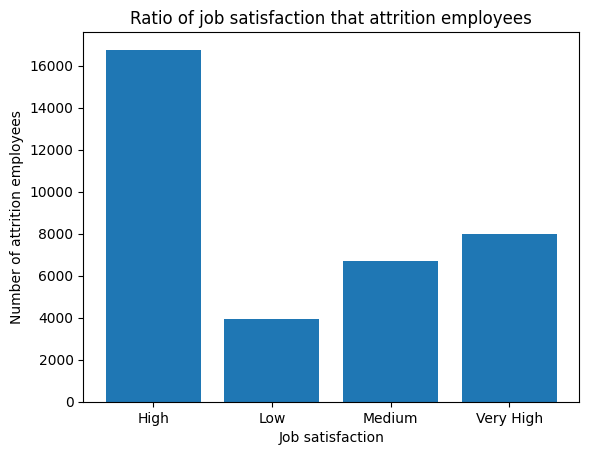

In [35]:
plt.Figure()
plt.bar(df[df['attrition']=='Left'].groupby('job_satisfaction')['attrition'].count().index, 
        df[df['attrition']=='Left'].groupby('job_satisfaction')['attrition'].count().values)

plt.title("Ratio of job satisfaction that attrition employees")
plt.xlabel("Job satisfaction")
plt.ylabel("Number of attrition employees")

---

#### what is the performance rating ratio for attrition employtees

Text(0, 0.5, 'Number of attrition employees')

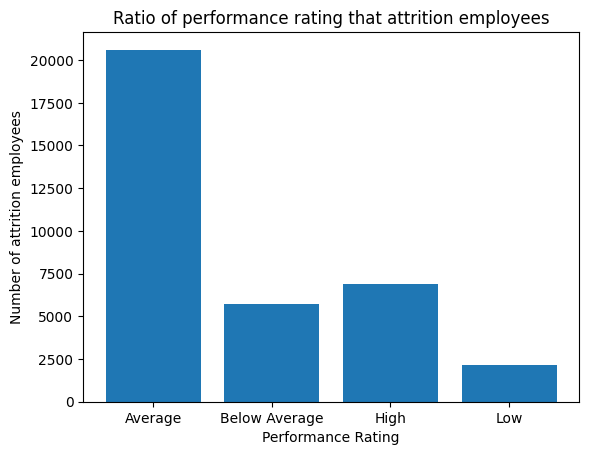

In [36]:
plt.Figure()
plt.bar(df[df['attrition']=='Left'].groupby('performance_rating')['attrition'].count().index, 
        df[df['attrition']=='Left'].groupby('performance_rating')['attrition'].count().values)

plt.title("Ratio of performance rating that attrition employees")
plt.xlabel("Performance Rating")
plt.ylabel("Number of attrition employees")

---

#### what is the working years at company for attrition employtees

Text(0, 0.5, 'Number of attrition employees')

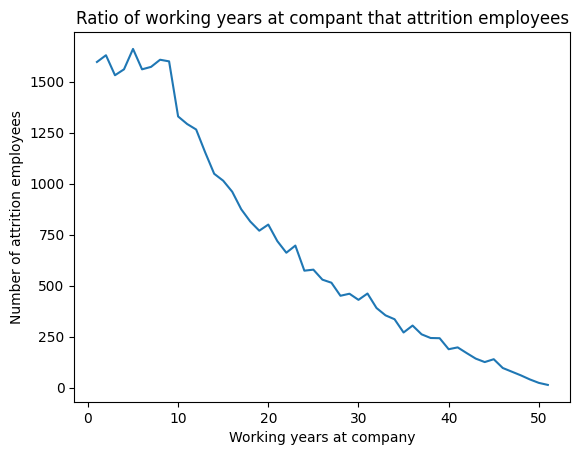

In [37]:
plt.Figure()
plt.plot(df[df['attrition']=='Left'].groupby('years_at_company')['attrition'].count().index, 
        df[df['attrition']=='Left'].groupby('years_at_company')['attrition'].count().values)

plt.title("Ratio of working years at compant that attrition employees")
plt.xlabel("Working years at company")
plt.ylabel("Number of attrition employees")

---

#### what is the company size ratio for attrition employtees

Text(0, 0.5, 'Number of attrition employees')

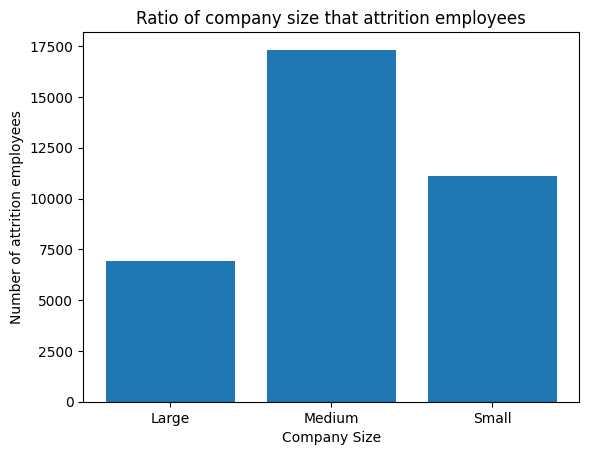

In [38]:
plt.Figure()
plt.bar(df[df['attrition']=='Left'].groupby('company_size')['attrition'].count().index.values, 
        df[df['attrition']=='Left'].groupby('company_size')['attrition'].count().values)

plt.title("Ratio of company size that attrition employees")
plt.xlabel("Company Size")
plt.ylabel("Number of attrition employees")

---

#### what is the work life balance ratio for attrition employtees

Text(0, 0.5, 'Number of attrition employees')

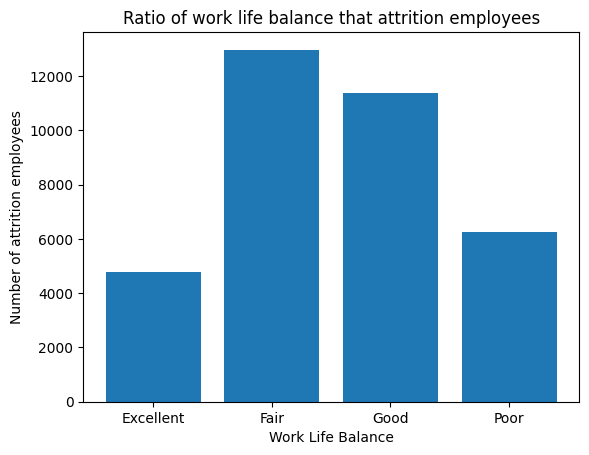

In [39]:
plt.Figure()
plt.bar(df[df['attrition']=='Left'].groupby('work-life_balance')['attrition'].count().index.values, 
        df[df['attrition']=='Left'].groupby('work-life_balance')['attrition'].count().values)

plt.title("Ratio of work life balance that attrition employees")
plt.xlabel("Work Life Balance")
plt.ylabel("Number of attrition employees")

---

#### what is the job level ratio for attrition employtees

Text(0, 0.5, 'Number of attrition employees')

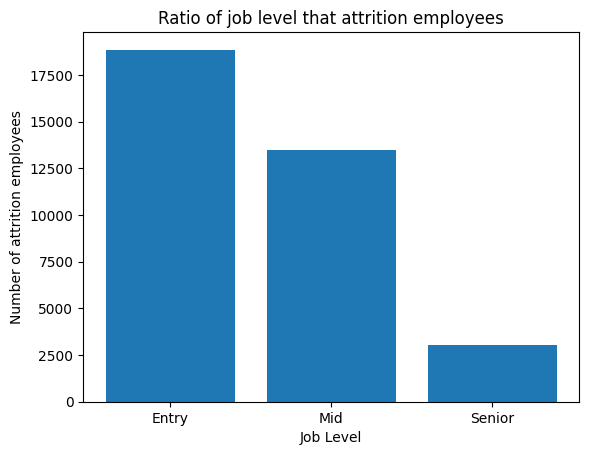

In [40]:
plt.Figure()
plt.bar(df[df['attrition']=='Left'].groupby('job_level')['attrition'].count().index.values, 
        df[df['attrition']=='Left'].groupby('job_level')['attrition'].count().values)

plt.title("Ratio of job level that attrition employees")
plt.xlabel("Job Level")
plt.ylabel("Number of attrition employees")

---

In [41]:
df.head()

,employee_id,age,gender,years_at_company,job_role,monthly_income,work-life_balance,job_satisfaction,performance_rating,number_of_promotions,...,number_of_dependents,job_level,company_size,company_tenure,remote_work,leadership_opportunities,innovation_opportunities,company_reputation,employee_recognition,attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


#### what is the number of promotions ratio for attrition employtees

Text(0, 0.5, 'Number of attrition employees')

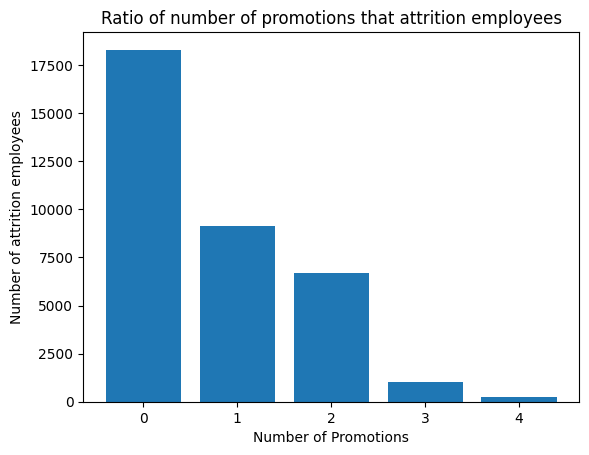

In [42]:
plt.Figure()
plt.bar(df[df['attrition']=='Left'].groupby('number_of_promotions')['attrition'].count().index.values, 
        df[df['attrition']=='Left'].groupby('number_of_promotions')['attrition'].count().values)

plt.title("Ratio of number of promotions that attrition employees")
plt.xlabel("Number of Promotions")
plt.ylabel("Number of attrition employees")

---

#### what is number of stayed employtees

In [43]:
int(df[df['attrition']=='Stayed'].count()['employee_id'])

39128

#### what is the ration of attrition employtees

In [44]:
# ration of attrition employees
f"{round((int(df[df['attrition']=='Left'].count()['employee_id']) / len(df))*100, 2)} %"

'47.48 %'

In [45]:
# Average income
round(float(df['monthly_income'].mean()), 2)

7299.38

In [46]:
df2 = {"values":df[df['attrition']=='Left'].groupby('performance_rating')['attrition'].count().values,
       'index':df[df['attrition']=='Left'].groupby('performance_rating')['attrition'].count().index}
df2 = pd.DataFrame(df2)
df2

,values,index
0,20607,Average
1,5746,Below Average
2,6889,High
3,2128,Low


---

In [22]:
df.columns

Index(['employee_id', 'age', 'gender', 'years_at_company', 'job_role',
       'monthly_income', 'work-life_balance', 'job_satisfaction',
       'performance_rating', 'number_of_promotions', 'overtime',
       'distance_from_home', 'education_level', 'marital_status',
       'number_of_dependents', 'job_level', 'company_size', 'company_tenure',
       'remote_work', 'leadership_opportunities', 'innovation_opportunities',
       'company_reputation', 'employee_recognition', 'attrition'],
      dtype='str')

In [21]:
df[df['attrition']=='Left'][df['company_reputation']=='Poor']

C:\Users\lenovo\AppData\Local\Temp\ipykernel_9052\3483542148.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['attrition']=='Left'][df['company_reputation']=='Poor']


,employee_id,age,gender,years_at_company,job_role,monthly_income,work-life_balance,job_satisfaction,performance_rating,number_of_promotions,...,number_of_dependents,job_level,company_size,company_tenure,remote_work,leadership_opportunities,innovation_opportunities,company_reputation,employee_recognition,attrition
11,9063,29,Female,6,Healthcare,8950,Poor,Medium,Low,2,...,0,Mid,Medium,38,No,No,No,Poor,Medium,Left
22,58984,39,Female,1,Finance,8079,Excellent,High,High,1,...,0,Entry,Medium,20,No,No,No,Poor,Low,Left
43,72189,34,Male,12,Finance,8274,Good,Very High,Below Average,0,...,1,Entry,Medium,36,No,No,No,Poor,Low,Left
45,34857,47,Female,36,Technology,8442,Fair,Low,High,1,...,0,Entry,Medium,67,Yes,No,No,Poor,Low,Left
50,30924,55,Female,6,Healthcare,9355,Fair,Very High,Average,0,...,3,Senior,Small,64,No,No,Yes,Poor,High,Left
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74456,24596,56,Female,14,Technology,11360,Good,Medium,High,0,...,1,Mid,Small,17,No,No,Yes,Poor,Medium,Left
74463,30208,53,Male,7,Healthcare,8253,Good,Low,High,1,...,1,Senior,Small,12,No,Yes,No,Poor,High,Left
74470,3185,21,Male,3,Education,3411,Fair,Very High,Average,2,...,5,Entry,Medium,8,No,No,No,Poor,High,Left
74472,12037,20,Male,8,Media,6241,Excellent,Very High,Average,1,...,2,Entry,Large,74,No,No,No,Poor,Low,Left


In [11]:
df[df['attrition']=='Left'].groupby('company_reputation')['attrition'].count()

company_reputation
Excellent     3259
Fair          7655
Good         15988
Poor          8468
Name: attrition, dtype: int64

In [ ]:
left_counts = df.query("attrition == 'Left'")['company_reputation'].value_counts()
left_counts

company_reputation
Good         15988
Poor          8468
Fair          7655
Excellent     3259
Name: count, dtype: int64

In [30]:
counts_table = pd.crosstab(df['company_reputation'], df['attrition'])

print(counts_table)

attrition            Left  Stayed
company_reputation               
Excellent            3259    4155
Fair                 7655    7131
Good                15988   21194
Poor                 8468    6648


---
---
---

In [64]:
# is the reason in مادي ولا معنوي

d = df.groupby('attrition')['monthly_income'].mean().reset_index(name='average_income')
d

fig = px.pie(d,
             names='attrition',
             values='average_income',
             title='Salaries Ration beteen stayed and left emplyees',
             hole=0.3,
             )

fig.update_traces(textinfo='percent+value')
fig.show()

In [63]:
# is the reason in مادي ولا معنوي

d = df.groupby('attrition')['number_of_dependents'].mean().reset_index(name='number_of_dependents')
d

fig = px.pie(d,
             names='attrition',
             values='number_of_dependents',
             title='Average Number of Dependents Ration beteen stayed and left emplyees',
             hole=0.3,
             )

fig.update_traces(textinfo='percent+value')
fig.show()

In [71]:
df[df['attrition']=='Left'].groupby('job_role')['attrition'].count().sort_values(ascending=False).reset_index(name='attrition_number')

,job_role,attrition_number
0,Technology,9099
1,Healthcare,8112
2,Education,7636
3,Media,5620
4,Finance,4903


In [87]:
d = df[df['attrition']=='Left'].groupby('job_role')['attrition'].count().sort_values(ascending=False).reset_index(name='attrition_number')

fig = px.bar(
    d, 
    x='job_role',
    y='attrition_number',
    title='Ratio of job domain and attrition number',
    labels={'job_role': 'Job Role', 'attrition_number': 'Number of Attritions'},
    text_auto='.1f',
    color='job_role'
)
# fig.update_traces(textinfo='percent+value')

fig.show()


In [78]:
d = df[df['attrition']=='Left'].groupby('employee_recognition')['attrition'].count().sort_values(ascending=False).reset_index(name='attrition_number')

fig = px.bar(
    d, 
    x='employee_recognition',
    y='attrition_number',
    title='Ratio of employee recognition and attrition number',
    # labels={'employee_recognition': 'Job employee_recognition', 'attrition_number': 'Number of Attritions'},
    text_auto='.1f',
    color='employee_recognition'
)

fig.show()


In [123]:
d = (df.assign(is_left=(df['attrition']=='Left').astype(int))
     .groupby('company_size')['is_left']
     .mean()
     .reset_index(name='attrition_rate')
     )
d['attrition_rate'] = d['attrition_rate']*100

d = d.sort_values(by='company_size', key=lambda x:x.map({'Small':1,'Medium':2,'Large':3}))

d['Percent'] = d.apply(lambda x: f"{round(x['attrition_rate'], 2)} %", axis=1)

fig = px.bar(
    d,
    x='company_size',
    y='attrition_rate',
    title='Attrition rate according to company reputation',
    # text_auto='0.1f',
    text='Percent',
    color='company_size',
    width=1000
)


fig.show()

In [116]:
d = (df.assign(is_left=(df['attrition']=='Left').astype(int))
     .groupby('company_reputation')['is_left']
     .mean()
     .reset_index(name='attrition_rate')
     )
d['attrition_rate'] = d['attrition_rate']*100

d = d.sort_values(by='company_reputation', key=lambda x:x.map({'Poor':1,'Fair':2,'Good':3,'Excellent':4}))

d['Percent'] = d.apply(lambda x: f"{x['attrition_rate']} %", axis=1)
d

,company_reputation,attrition_rate,Percent
3,Poor,56.020111,56.020111140513364 %
1,Fair,51.771946,51.77194643581766 %
2,Good,42.999301,42.999300736915714 %
0,Excellent,43.957378,43.957377933639066 %


In [ ]:
d = (df.assign(is_left=(df['attrition']=='Left').astype(int))
     .groupby('company_reputation')['is_left']
     .mean()
     .reset_index(name='attrition_rate')
     )
d['attrition_rate'] = d['attrition_rate']*100

d = d.sort_values(by='company_reputation', key=lambda x:x.map({'Poor':1,'Fair':2,'Good':3,'Excellent':4}))

# d['percent'] = str(d['attrition_rate']) + ' %'

d['Percent'] = d.apply(lambda x: f"{round(x['attrition_rate'], 2)} %", axis=1)

fig = px.bar(
    d,
    x='company_reputation',
    y='attrition_rate',
    title='Attrition rate according to company reputation',
    # text_auto='0.1f',
    text='Percent',
    color='company_reputation',
    width=1000
)


fig.show()

In [97]:
d = df[df['attrition']=='Left'].groupby('number_of_promotions')['attrition'].count().sort_values(ascending=False).reset_index(name='attrition_number')

total = d['attrition_number'].sum()
d['Percent'] = (d['attrition_number'] / total) * 100

d['Percent'] = d.apply(lambda row: f"{row['attrition_number']}   ({row['Percent']:.1f}%)", axis=1)
d


,number_of_promotions,attrition_number,Percent
0,0,18304,18304.0 (51.8%)
1,1,9147,9147.0 (25.9%)
2,2,6679,6679.0 (18.9%)
3,3,1010,1010.0 (2.9%)
4,4,230,230.0 (0.7%)


In [101]:
d = df[df['attrition']=='Left'].groupby('number_of_promotions')['attrition'].count().sort_values(ascending=False).reset_index(name='attrition_number')

total = d['attrition_number'].sum()
d['Percent'] = (d['attrition_number'] / total) * 100

d['Percent'] = d.apply(lambda row: f"{row['attrition_number']}   ({row['Percent']:.1f}%)", axis=1)

fig = px.bar(
    d, 
    x='number_of_promotions',
    y='attrition_number',
    title='Ratio of number of promotions and attrition number',
    color='number_of_promotions',
    text='Percent'
)

fig.show()


### According to Employee

In [ ]:
d = df[df['attrition']=='Left'].groupby('job_satisfaction')['attrition'].count().sort_values(ascending=False).reset_index(name='attrition_number')

total = d['attrition_number'].sum()
d['Percent'] = (d['attrition_number'] / total) * 100

d['Percent'] = d.apply(lambda row: f"{row['attrition_number']}   ({row['Percent']:.1f}%)", axis=1)

fig = px.bar(
    d, 
    x='job_satisfaction',
    y='attrition_number',
    title='Ratio of job satisfaction and attrition number',
    color='job_satisfaction',
    text='Percent'
)

fig.show()


In [127]:
df.head()

,employee_id,age,gender,years_at_company,job_role,monthly_income,work-life_balance,job_satisfaction,performance_rating,number_of_promotions,...,number_of_dependents,job_level,company_size,company_tenure,remote_work,leadership_opportunities,innovation_opportunities,company_reputation,employee_recognition,attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [ ]:
# df[df['attrition']=='Left'].groupby('job_satisfaction')['attrition'].count().sort_values(ascending=False)


d = df[df['attrition']=='Left'].groupby('performance_rating')['attrition'].count().sort_values(ascending=False).reset_index(name='attrition_number')

total = d['attrition_number'].sum()
d['Percent'] = (d['attrition_number'] / total) * 100

d['Percent'] = d.apply(lambda row: f"{row['attrition_number']}   ({row['Percent']:.1f}%)", axis=1)

fig = px.bar(
    d, 
    x='performance_rating',
    y='attrition_number',
    title='Ratio of performance rating and attrition number',
    color='performance_rating',
    text='Percent'
)

fig.show()


In [134]:
d = df[df['attrition']=='Left'].groupby('remote_work')['attrition'].count().sort_values(ascending=False).reset_index(name='attrition_number')

total = d['attrition_number'].sum()
d['Percent'] = (d['attrition_number'] / total) * 100

d['Percent'] = d.apply(lambda row: f"{row['attrition_number']}   ({row['Percent']:.1f}%)", axis=1)

fig = px.bar(
    d, 
    x='remote_work',
    y='attrition_number',
    title='Ratio of remote work and attrition number',
    color='remote_work',
    text='Percent'
)

fig.show()


In [165]:
d = df.groupby('attrition')['distance_from_home'].mean().sort_values(ascending=False).reset_index(name='distance_from_home')

fig = px.bar(
    d, 
    x='attrition',
    y='distance_from_home',
    text_auto='0.1f',
    title='Average distance from home for stayed and left employees',
    color='distance_from_home',
)

fig.show()


In [167]:
d = df[df['attrition']=='Left'].groupby('job_satisfaction')['attrition'].count().sort_values(ascending=False).reset_index(name='attrition_number')

total = d['attrition_number'].sum()
d['Percent'] = (d['attrition_number'] / total) * 100

d['Percent'] = d.apply(lambda row: f"{row['attrition_number']}   ({row['Percent']:.1f}%)", axis=1)

fig = px.bar(
    d, 
    x='job_satisfaction',
    y='attrition_number',
    title='Ratio of job satisfaction and attrition number',
    color='job_satisfaction',
    text='Percent'
)

fig.show()


In [ ]:
d = df[df['attrition']=='Left'].groupby('job_level')['attrition'].count().sort_values(ascending=False).reset_index(name='attrition_number')

total = d['attrition_number'].sum()
d['Percent'] = (d['attrition_number'] / total) * 100

d['Percent'] = d.apply(lambda row: f"{row['attrition_number']}   ({row['Percent']:.1f}%)", axis=1)

fig = px.bar(
    d, 
    x='job_level',
    y='attrition_number',
    title='Ratio of job level and attrition number',
    color='job_level',
    text='Percent'
)

fig.show()


In [177]:
d = df[df['attrition']=='Left'].groupby('work-life_balance')['attrition'].count().sort_values(ascending=False).reset_index(name='attrition_number')

d = d.sort_values(by='work-life_balance', key=lambda x:x.map({'Poor':1,'Fair':2,'Good':3,'Excellent':4}))

total = d['attrition_number'].sum()
d['Percent'] = (d['attrition_number'] / total) * 100

d['Percent'] = d.apply(lambda row: f"{row['attrition_number']}   ({row['Percent']:.1f}%)", axis=1)

fig = px.bar(
    d, 
    x='work-life_balance',
    y='attrition_number',
    title='Ratio of job level and attrition number',
    color='work-life_balance',
    text='Percent'
)

fig.show()


---